# Autoencoder with ACCESS-OM2

Autoencoder with ACCESS-OM2 Ocean Heat Content Data

This notebook trains an autoencoder on ocean heat content and surface heat flux data from the ACCESS-OM2 model using partial convolutions to handle land-masked regions.

In [23]:
# -----------------------------------------------------------------------------
# Cell purpose: import dependencies and define paths/device for full workflow.
# Outcome: pipeline/data/model/plot modules are loaded and local utils are importable.
# -----------------------------------------------------------------------------
# System and path handling
import sys
from pathlib import Path

# Data handling
import numpy as np
import pandas as pd
import xarray as xr

# PyEarthTools pipeline
import pyearthtools.data as petdata
import pyearthtools.pipeline as petpipe
import pyearthtools.training

# Deep learning
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import lightning as L

# Visualization
import matplotlib.pyplot as plt

# Configure device and random seed
torch.manual_seed(42)
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

# Source data and code directories
userbase = "/g/data/nm47/txs156/"
# Taimoor's repobase:
# repobase = "/home/156/txs156/uom/OM2-emulator/"
# Ryan's repobase:
# repobase = "/home/561/rmh561/ML/OM2-emulator/"
# Navid's repobase:
repobase = "/home/552/nc3020/gdata/OM2-emulator/"

# Add the src directory to the Python path (relative to notebook location)
src_path = Path(repobase) / "src"
sys.path.insert(0, str(src_path))

# Import the ACCESS_OHC data accessor from om2_data_utils module
from om2_data_utils import ACCESS_OHC
from om2_model_utils import PartialConv2d


import warnings

In [24]:
# Define a function to build the normalisations depending on the strategy -- should be moved to a separate Python function file
def build_normalisation(file, norm_strat, norm_variables, time_window, train_end, mask, mask_var_index=1):
    #Load the xarray data and time/variable slice it. 
    ds_stats = xr.open_dataset(file)
    times = pd.date_range(**time_window)
    ds_stats = ds_stats.sel(time=times, method = "nearest")
    ds_stats = ds_stats[norm_variables]

    # Load the mask if mask=True 
    if mask:
        mask_var = norm_variables[mask_var_index]
        warnings.warn(f"Assuming {mask_var} has NaNs at t=0 to indicate land mask.")
        mask_xr = xr.where(np.isnan(ds_stats[mask_var].isel(time=0)), 0, 1)
        masked_stats = ds_stats.where(mask_xr == 1)
    else: 
        warnings.warn("Normalising without taking into account land mask")
        masked_stats = ds_stats
        
    # Align spatial dimension names with the pipeline (Sort uses latitude/longitude).
    rename_map = {}
    if "yt_ocean" in masked_stats.dims:
        rename_map["yt_ocean"] = "latitude"
    if "xt_ocean" in masked_stats.dims:
        rename_map["xt_ocean"] = "longitude"
    if rename_map:
        masked_stats = masked_stats.rename(rename_map)

    # The below if statements define the mean and stds. 
    # To avoid data leakage, only the training data is used for mean/std calculation
    if norm_strat == "Global_in_time":
        # 1) Global stats (scalar per variable)
        mean_stats = masked_stats.sel(time=slice(times[0], train_end)).mean(dim=("time", "latitude", "longitude"), skipna=True)
        std_stats = masked_stats.sel(time=slice(times[0], train_end)).std(dim=("time", "latitude", "longitude"), skipna=True)
    elif norm_strat == "Spatial_in_time":
        # 2) Spatial stats (per-gridcell over all times)
        mean_stats = masked_stats.sel(time=slice(times[0], train_end)).mean(dim="time", skipna=True)
        std_stats = masked_stats.sel(time=slice(times[0], train_end)).std(dim="time", skipna=True)
    elif norm_strat == "Spatial_climatology":
        # 3) Spatial climatology (month-wise per gridcell) then tile over all years.
        mean_stats = masked_stats.sel(time=slice(times[0], train_end)).groupby("time.month").mean(dim="time", skipna=True)
        std_stats = (masked_stats.sel(time=slice(times[0], train_end)).groupby("time.month")\
                     - mean_stats).groupby('time.month').std(dim="time", skipna=True)

        month_indexer = xr.DataArray(
            masked_stats.time.dt.month.values,
            coords={"time": masked_stats.time.values},
            dims="time",
        )
        mean_stats = mean_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")
        std_stats = std_stats.sel(month=month_indexer).drop_vars("month", errors="ignore")
    else: 
        raise ValueError("No valid normlaisation strategy provided. Options are Global_in_time, Spatial_in_time, and Spatial_climatology")

    # Transform mean and std to Datasets so co-ordinates align with the raw data
    mean_stats_ds = xr.Dataset({var: mean_stats[var] for var in norm_variables})
    std_stats_ds  = xr.Dataset({var: std_stats[var]  for var in norm_variables})

    # Define pipeline normalisation operations for the strategy.
    pipelines_normed = petpipe.operations.xarray.normalisation.Evaluated(
                        normalisation_eval="(sample - mean) / deviation",
                        unnormalisation_eval="(sample * deviation) + mean",
                        mean = mean_stats_ds,
                        deviation = std_stats_ds)
    
    return mask_xr, pipelines_normed

In [25]:
# Setup the normalisation
time_start = '2000-01'
train_end = "2015-03"
val_start = "2015-04"
time_end = '2018-12'
time_interval = '1MS'
norm_variables = ["ocean_heat_content_2d", "total_surface_heat_flx"]
norm_strat = "Spatial_climatology" 
datapath = userbase + "OM2-emulator/data/1deg_ocean_heat_emulator_data.nc"

mask, normalisation = build_normalisation(datapath, norm_strat, norm_variables, time_window = dict(start=time_start, end=time_end, freq=time_interval),\
                                          train_end = train_end, mask = True)
mean = normalisation._initialisation["mean"]
deviation = normalisation._initialisation["deviation"]

/jobfs/171664977.gadi-pbs/ipykernel_2694255/1271418874.py:12: UserWarning: Assuming total_surface_heat_flx has NaNs at t=0 to indicate land mask.
  warnings.warn(f"Assuming {mask_var} has NaNs at t=0 to indicate land mask.")


In [26]:
# Set up accessor for the ACCESS data
ACCESS_OHC_accessor = ACCESS_OHC(
    ["area_t", "ocean_heat_content_2d", "total_surface_heat_flx"],
    root=userbase + "OM2-emulator/data/",
)

## Setup PyEarthTools data accessor and pipeline

In [27]:
# -----------------------------------------------------------------------------
# Cell purpose: assemble one PET pipeline mode and load full
# time series (not just one iterator sample).
# -----------------------------------------------------------------------------

pipeline_i = petpipe.Pipeline(
    ACCESS_OHC_accessor,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    petdata.transforms.variables.Drop(['area_t']),
    petpipe.operations.xarray.select.SelectDataset(norm_variables),
    petpipe.operations.xarray.Sort(order=norm_variables, strict=True),
    petpipe.operations.xarray.reshape.Dimensions(["time", "latitude", "longitude"]),
    normalisation,
    petdata.transforms.coordinates.Drop(['geolat_t', 'geolon_t']),
    # The latest branch of PET implements Inf --> 0, so I have this here. 
    # But the latest tagged release does not do anything with these kwargs.
    petpipe.operations.xarray.values.FillNan(0, posinf=0, neginf=0),
    petpipe.operations.xarray.conversion.ToNumpy(),
    petpipe.operations.numpy.reshape.Rearrange('c t h w -> t c h w'),
    iterator=petpipe.iterators.DateRange(time_start, time_end, interval="1 month"),
)

In [28]:
# We define the training-testing split here!
splits = {
    "train_split": petpipe.iterators.DateRange(
        "2000-01", "2015-04", interval="1 month"
    ),
    "valid_split": petpipe.iterators.DateRange(
        "2015-04", "2019-01", interval="1 month"
    ),
}

## Define the model using Lightning and Torch

In [29]:
# The below is a Lightning wrapper that is used to train the autoencoder. 
# This was implemented so that we could interface with PET's training workflow
# Which uses Lightning. 

# See GH issue: https://github.com/ACCESS-Community-Hub/PyEarthTools/issues/266
# NB: This wrapper should probably also move out of this notebook

class LitAutoEncoder(L.LightningModule):
    def __init__(self, model, mask, lr=1e-4):
        super().__init__()
        self.model = model
        self.lr = lr
        self.criterion = nn.L1Loss()

        # Persist mask with device movement/checkpoints
        self.register_buffer(
            "mask",
            torch.as_tensor(mask, dtype=torch.float32).unsqueeze(0).unsqueeze(0)
        )

    def forward(self, x):
        # x: [B, C, H, W]
        mask = self.mask.expand(x.shape[0], 1, x.shape[2], x.shape[3])
        return self.model(x, mask)
        
    def _shared_step(self, batch):
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        if x.ndim == 5 and x.shape[1] == 1:
            x = x[:, 0]
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)
        x_hat = self.forward(x)
        mask = self.mask.expand_as(x[:, :1])
        loss = torch.abs(x_hat - x)
        return (loss * mask).sum() / mask.sum().clamp_min(1.0)
    
    def training_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("train_loss", loss, prog_bar=True)
        return loss
    
    def validation_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("valid_loss", loss, prog_bar=True)
        return loss
    
    def test_step(self, batch, batch_idx):
        loss = self._shared_step(batch)
        self.log("test_loss", loss, prog_bar=True)
        return loss

    def predict_step(self, batch, batch_idx):
        x = batch[0] if isinstance(batch, (tuple, list)) else batch

        if x.ndim == 5 and x.shape[1] == 1:
            x = x[:, 0]
            
        x = torch.nan_to_num(x, nan=0.0, posinf=0.0, neginf=0.0)

        x_hat = self.forward(x)

        return {
            "x": x.detach().cpu(),
            "x_hat": x_hat.detach().cpu(),
        }


    def configure_optimizers(self):
        return optim.Adam(self.parameters(), lr=self.lr)

In [30]:
# Define the Autoencoder using PyTorch -- probably should also be moved out :) 

class AutoEncoder(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(AutoEncoder, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        self.dec1 = PartialConv2d(64, 32, kernel_size=7, stride=1, padding=3)
        self.dec2 = PartialConv2d(32, 16, kernel_size=3, stride=1, padding=1)
        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()
    
    def encode(self, x, mask):
        """Encoder: returns latent representation and updated mask"""
        x, mask = self.enc1(x, mask)
        x = self.relu(x)
        x, mask = self.enc2(x, mask)
        x = self.relu(x)
        x, mask = self.enc3(x, mask)
        x = self.relu(x)
        return x, mask
    
    def decode(self, x, mask):
        """Decoder: takes latent representation and reconstructs output"""
        # upsample 1
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # upsample 2
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # final conv
        x, mask = self.dec3(x, mask)

        # Note that here we were using nn.Sigmoid, which 
        # Forces the prediction to be positive, hence the single-signed estimates.
        reconstructed = x
        
        return reconstructed, mask
    
    def forward(self, x, mask):
        # Store input size for later
        input_h, input_w = x.shape[2], x.shape[3]

        # Encoder
        latent, latent_mask = self.encode(x, mask)

        # Decoder
        reconstructed, final_mask = self.decode(latent, latent_mask)
        
        # Crop to match input size (handles rounding errors from upsampling)
        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed


class UNet(nn.Module):

    def __init__(self,
                 input_channel_count=2,
                 output_channel_count=2):

        super(UNet, self).__init__()

        # ---------- Encoder ----------
        self.enc1 = PartialConv2d(input_channel_count, 16, kernel_size=4, stride=2, padding=1)
        self.enc2 = PartialConv2d(16, 32, kernel_size=3, stride=2, padding=1)
        self.enc3 = PartialConv2d(32, 64, kernel_size=7, stride=1, padding=3)

        # ---------- Decoder ----------
        # After first upsample, latent has 64 channels and skip2 has 32 channels
        self.dec1 = PartialConv2d(64 + 32, 32, kernel_size=7, stride=1, padding=3)

        # After second upsample, dec1 has 32 channels and skip1 has 16 channels
        self.dec2 = PartialConv2d(32 + 16, 16, kernel_size=3, stride=1, padding=1)

        self.dec3 = PartialConv2d(16, output_channel_count, kernel_size=4, stride=1, padding=2)

        self.relu = nn.ReLU()

    def encode(self, x, mask):
        """Encoder: returns latent representation, updated mask, and skip features"""

        x1, mask1 = self.enc1(x, mask)
        x1 = self.relu(x1)

        x2, mask2 = self.enc2(x1, mask1)
        x2 = self.relu(x2)

        latent, latent_mask = self.enc3(x2, mask2)
        latent = self.relu(latent)

        return latent, latent_mask, x1, mask1, x2, mask2

    def decode(self, x, mask, x1, mask1, x2, mask2):
        """Decoder with U-Net skip connections"""

        # ---------- Upsample to enc2 resolution ----------
        x = F.interpolate(x, size=x2.shape[2:], mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, size=mask2.shape[2:], mode="nearest")

        x = torch.cat([x, x2], dim=1)
        # mask = torch.cat([mask, mask2], dim=1)

        x, mask = self.dec1(x, mask)
        x = self.relu(x)

        # ---------- Upsample to enc1 resolution ----------
        x = F.interpolate(x, size=x1.shape[2:], mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, size=mask1.shape[2:], mode="nearest")

        x = torch.cat([x, x1], dim=1)
        # mask = torch.cat([mask, mask1], dim=1)

        x, mask = self.dec2(x, mask)
        x = self.relu(x)

        # ---------- Final upsample to input resolution ----------
        x = F.interpolate(x, scale_factor=2, mode="bilinear", align_corners=False)
        mask = F.interpolate(mask, scale_factor=2, mode="nearest")

        x, mask = self.dec3(x, mask)

        return x, mask

    def forward(self, x, mask):
        input_h, input_w = x.shape[2], x.shape[3]

        latent, latent_mask, x1, mask1, x2, mask2 = self.encode(x, mask)

        reconstructed, final_mask = self.decode(
            latent, latent_mask,
            x1, mask1,
            x2, mask2,
        )

        reconstructed = reconstructed[:, :, :input_h, :input_w]

        return reconstructed

## Initialize model and prepare data for training

In [31]:
# Define the "base" Autoencoder model as before
# base_model = AutoEncoder(
#     input_channel_count=len(norm_variables),
#     output_channel_count=len(norm_variables),
# )

base_model = UNet(
    input_channel_count=len(norm_variables),
    output_channel_count=len(norm_variables),
)

In [32]:
# Use the lightning wrapper to define the Autoencoder and mask 
lightning_model = LitAutoEncoder(
    model=base_model,
    mask=mask.values,
    lr=1e-4,
)

In [33]:
# Use PET's PipelineLightningDataModule to define the data that will be loaded
# into the Lightning wrapper
datamodule = pyearthtools.training.data.lightning.PipelineLightningDataModule(
    pipeline_i,
    **splits,
    batch_size=32,
    num_workers=0,
)

In [34]:
%%time
# PET training's default mode is to do expensive loading of the datamodule.train_dataloader() every Epoch. 
# This function instead loads the datamodule into memory once, moving from PET --> PyTorch. 
# The shuffle = false kwarg is so that the data is not randomised in time, so
# the un-normalisation later will work

def make_fast_dl(pet_dl, batch_size=8, shuffle=False, drop_last=False):
    xs = []

    for batch in pet_dl:
        x = batch[0] if isinstance(batch, (tuple, list)) else batch
        xs.append(x.detach().cpu())

    xs = torch.cat(xs, dim=0)

    return DataLoader(
        TensorDataset(xs),
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=0,
        drop_last=drop_last,
    )

# This call creates the datamodule.train_dataloader() and datamodule.val_dataloader() objects
# Based on the ** splits in the above cell
datamodule.setup("fit")

# Now load the training and validation DataLoaders into memory ONCE
fast_train_dl = make_fast_dl(
    datamodule.train_dataloader(),
    batch_size=32,
    shuffle=False,
    drop_last=False,
)

fast_valid_dl = make_fast_dl(
    datamodule.val_dataloader(),
    batch_size=32,
    shuffle=False,
    drop_last=False,
)

CPU times: user 30.6 s, sys: 24.3 s, total: 54.9 s
Wall time: 43.3 s


In [35]:
# This cell defines the Lightning Trainer. 
# PET's native training pyearthtools.training.lightning.Train 
# expects the PipelineLightningDataModule, but
# it is too slow for our current set-up to be implemented here. 
# it takes about 5 mins per epoch

# I have a GH issue on this too: https://github.com/ACCESS-Community-Hub/PyEarthTools/issues/265

trainer = L.Trainer(
    max_epochs=200,
    num_sanity_val_steps=0,
    accelerator="gpu",
    devices=1,
    logger=False,
    enable_checkpointing=False,
    enable_model_summary=False,
)

# This is the bit of code which actually does the training over x epochs. 
trainer.fit(
    model=lightning_model,
    train_dataloaders=fast_train_dl,
    val_dataloaders=fast_valid_dl,
)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
HPU available: False, using: 0 HPUs
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/envs/pet/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.
/opt/conda/envs/pet/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

`Trainer.fit` stopped: `max_epochs=200` reached.


In [36]:
# Now we use the trained Autoencoder to predict both the training and validation data
train_preds = trainer.predict(lightning_model, dataloaders=fast_train_dl)
validation_preds = trainer.predict(lightning_model, dataloaders=fast_valid_dl)

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/opt/conda/envs/pet/lib/python3.11/site-packages/lightning/pytorch/trainer/connectors/data_connector.py:433: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=11` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |          | 0/? [00:00<?, ?it/s]

In [37]:
# The PyTorch output comes as a list of batches, so we concatenate them to get the full array
x_train = torch.cat([p["x"] for p in train_preds], dim=0).cpu().numpy()
xhat_train = torch.cat([p["x_hat"] for p in train_preds], dim=0).cpu().numpy()
x_validation = torch.cat([p["x"] for p in validation_preds], dim=0).cpu().numpy()
xhat_validation = torch.cat([p["x_hat"] for p in validation_preds], dim=0).cpu().numpy()

# The PET un-normalisation expects all times in the array, so we re-concatenate 
# the training and validation data
x_all = np.concatenate([x_train, x_validation], axis=0)
xhat_all = np.concatenate([xhat_train, xhat_validation], axis=0)

In [38]:
# Undo the PET pipeline
actual_data = pipeline_i.undo(x_all)
predicted_data = pipeline_i.undo(xhat_all)

/opt/conda/envs/pet/lib/python3.11/site-packages/pyearthtools/utils/data/converter.py:326: RuntimeWarning: Incoming and expected shape don't match. (2, 228, 300, 360) != (2, 1, 300, 360). Dropping conflicting coordinates.
  warnings.warn(


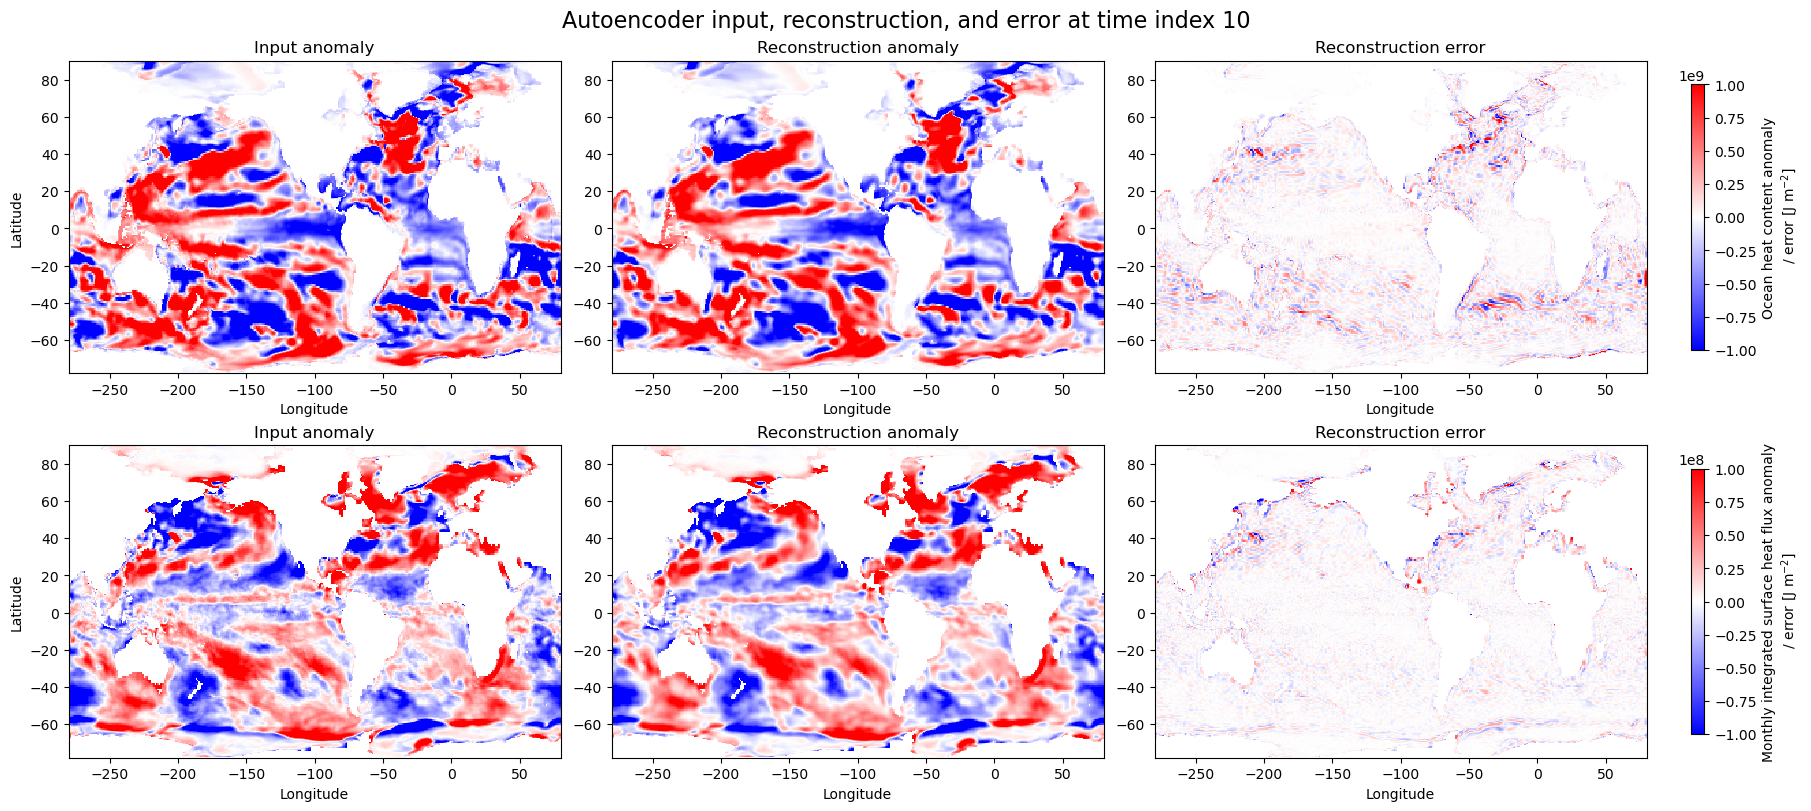

In [39]:
# Now we compare the actual and prediction, looks good!! 

month_seconds = 30 * 24 * 3600
itime = 10

fig, axes = plt.subplots(
    nrows=2,
    ncols=3,
    figsize=(18, 8),
    constrained_layout=True,
)

# -------------------------
# Data
# -------------------------
ohc_fields = [
    (actual_data - mean).ocean_heat_content_2d.isel(time=itime),
    (predicted_data - mean).ocean_heat_content_2d.isel(time=itime),
    (predicted_data - actual_data).ocean_heat_content_2d.isel(time=itime),
]

hf_fields = [
    ((actual_data - mean) * month_seconds).total_surface_heat_flx.isel(time=itime),
    ((predicted_data - mean) * month_seconds).total_surface_heat_flx.isel(time=itime),
    ((predicted_data - actual_data) * month_seconds).total_surface_heat_flx.isel(time=itime),
]

col_titles = [
    "Input anomaly",
    "Reconstruction anomaly",
    "Reconstruction error",
]

# -------------------------
# Plot settings
# -------------------------
ohc_vmin, ohc_vmax = -1e9, 1e9
hf_vmin, hf_vmax = -1e8, 1e8
cmap = plt.cm.bwr

# -------------------------
# OHC row
# -------------------------
ohc_mappables = []
for j, field in enumerate(ohc_fields):
    p = field.plot(
        ax=axes[0, j],
        vmin=ohc_vmin,
        vmax=ohc_vmax,
        cmap=cmap,
        add_colorbar=False,
    )
    ohc_mappables.append(p)
    axes[0, j].set_title(col_titles[j])
    axes[0, j].set_xlabel("Longitude")
    axes[0, j].set_ylabel("Latitude" if j == 0 else "")

# -------------------------
# Heat flux row
# -------------------------
hf_mappables = []
for j, field in enumerate(hf_fields):
    p = field.plot(
        ax=axes[1, j],
        vmin=hf_vmin,
        vmax=hf_vmax,
        cmap=cmap,
        add_colorbar=False,
    )
    hf_mappables.append(p)
    axes[1, j].set_title(col_titles[j])
    axes[1, j].set_xlabel("Longitude")
    axes[1, j].set_ylabel("Latitude" if j == 0 else "")

# -------------------------
# One colorbar per row
# -------------------------
cbar_ohc = fig.colorbar(
    ohc_mappables[0],
    ax=axes[0, :],
    orientation="vertical",
    shrink=0.85,
    pad=0.02,
)
cbar_ohc.set_label("Ocean heat content anomaly\n / error [J m$^{-2}$]")

cbar_hf = fig.colorbar(
    hf_mappables[0],
    ax=axes[1, :],
    orientation="vertical",
    shrink=0.85,
    pad=0.02,
)
cbar_hf.set_label("Monthly integrated surface heat flux anomaly\n / error [J m$^{-2}$]")

fig.suptitle(
    f"Autoencoder input, reconstruction, and error at time index {itime}",
    fontsize=16,
)

plt.savefig(repobase + 'figures/Example_output.png', dpi=150, bbox_inches='tight')

plt.show()